# Historical Synthetic Must: Calibration and Estimability

This notebook independently reproduces the calibration, Fisher information, eigen-direction and profile-likelihood workflow used in `fermentation_estimability_old_vs_lot1`, restricted to the historical `synthetic` medium.

## tl;dr

The numerical conclusions are generated below from a fresh medium-specific fit. The final report states which parameters are locally supported, which remain confounded, and how well the fitted model reproduces each observed state.

## Context & Methods

The core parameter block is re-estimated in log space using the same bounds, residual scaling and deterministic multistart as the reference notebook. The local Fisher information matrix is

$$
F(\theta) = J(\theta)^\mathsf{T} J(\theta),
$$

where $J$ is the Jacobian of scaled residuals with respect to log-parameters. Profile likelihood is used as a nonlinear check for `Kd0` and `qN`; the three-point grid is a screening profile, not a final confidence interval.

No continuous process-sensor files are added to the synthetic historical subset in this notebook.

### Key Assumptions

- Secondary and aroma parameters are evaluated conditionally at the shared prior values; only the core fermentation block is re-estimated here.
- CO2 flow and cumulative CO2 production are different observables. Sensor values remain diagnostic until a gas-liquid observation layer is calibrated.
- Missing observations stay missing. They are never replaced with zeros.


In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import display, Image

from laboratory_2026 import run_estimability_historical_by_medium as analysis

MEDIUM = 'synthetic'
RESULTS = analysis.results_dir(MEDIUM)


## Run Analysis

In [2]:
analysis.run_medium_analysis(
    MEDIUM,
    profile_parameters=("Kd0", "qN"),
    grid_points=3,
    fit_nfev=300,
    profile_nfev=45,
    step=0.04,
)

[load] historical synthetic


[fit-core] historical_synthetic_only


[fim-core] historical_synthetic_only


[fim-extended] historical_synthetic_only


[profile] historical_synthetic_only: Kd0, qN


[fit-diagnostics] historical_synthetic_only


[done] historical synthetic analysis complete


## Data

In [3]:
batch_summary = pd.read_csv(RESULTS / "batch_summary.csv")
support = pd.read_csv(RESULTS / "measurement_support.csv")
display(batch_summary)
display(support)

,case,medium,batch,n_time,t_min_h,t_max_h,X0,Xd0,N0,G0,F0,E0,Gly0,n_core_obs,n_secondary_obs,pulses
0,historical_synthetic_only,synthetic,MS007,10,0.0,213.0,0.33300,0.11700,0.224,125.34,120.52,0.0,0.34,57,9,N:24@0.1
1,historical_synthetic_only,synthetic,MS008,10,0.0,213.0,0.32835,0.12165,0.218,124.28,119.63,0.0,0.38,56,9,N:96@0.1
2,historical_synthetic_only,synthetic,MS009,10,0.0,213.0,0.33750,0.11250,0.236,120.89,114.19,0.0,0.38,57,9,N:24@0.1
3,historical_synthetic_only,synthetic,MS010,10,0.0,213.5,0.56100,0.00000,0.221,124.65,113.21,0.0,0.43,56,9,N:24@0.1
4,historical_synthetic_only,synthetic,MS011,10,0.0,213.5,0.36975,0.23025,0.218,123.57,119.77,0.0,0.80,56,9,N:96@0.1
5,historical_synthetic_only,synthetic,MS012,10,0.0,213.5,0.47580,0.00000,0.223,122.56,114.23,0.0,0.66,56,9,N:96@0.1
6,historical_synthetic_only,synthetic,MS013,9,0.0,213.0,0.45975,0.00000,0.218,125.07,116.20,0.0,0.27,51,8,N:72@0.1
7,historical_synthetic_only,synthetic,MS014,9,0.0,213.0,0.48495,0.00000,0.226,127.15,126.50,0.0,0.21,51,8,N:72@0.1
8,historical_synthetic_only,synthetic,MS015,9,0.0,213.0,0.38130,0.06870,0.220,121.91,118.49,0.0,0.22,51,8,N:72@0.1
9,historical_synthetic_only,synthetic,MS016,9,0.0,208.0,0.49080,0.00000,0.214,125.22,116.88,0.0,0.08,51,8,N:72@0.1


,state,n_observations,n_batches_with_observations,used_in_core_fit,used_in_extended_fim
0,X,76,10,True,True
1,Xd,86,10,True,True
2,N,83,10,True,True
3,G,86,10,True,True
4,F,86,10,True,True
5,E,40,10,True,True
6,Gly,85,10,True,True
7,Pyr,86,10,False,True
8,AcAld,0,0,False,True
9,Acetate,0,0,False,True


## Results

In [4]:
fit_candidates = pd.read_csv(RESULTS / "core_fit_candidate_summary.csv")
fit_summary = pd.read_csv(RESULTS / "core_fit_summary.csv")
fim_metrics = pd.read_csv(RESULTS / "fim_metrics.csv")
display(fit_candidates[["case", "seed", "final_wsse", "n_residuals", "nfev", "success"]])
display(fit_summary)
display(fim_metrics)

,case,seed,final_wsse,n_residuals,nfev,success
0,historical_synthetic_only,seed_default,9378.762878,542,15,True
1,historical_synthetic_only,qN_up_25pct,9316.541442,542,15,True
2,historical_synthetic_only,Kd0_up_2x,9310.002682,542,11,True
3,historical_synthetic_only,qN_up_25pct_Kd0_up_2x,9334.922103,542,14,True
4,historical_synthetic_only,profile_center_Kd0_nuisance,9304.154684,542,8,True
5,historical_synthetic_only,profile_center_Kd0_release,9302.472794,542,7,True
6,historical_synthetic_only,profile_center_qN_nuisance,9302.472796,542,8,True
7,historical_synthetic_only,profile_center_qN_release,9302.472796,542,8,True


,fit,n_batches,mediums,parameters,n_parameters,success,status,message,nfev,initial_wsse,final_wsse,n_residuals,dof,wsse_per_residual,wsse_per_dof,l2_lambda,l2_parameters,best_seed
0,historical_synthetic_only,10,synthetic,"mu0,qN,betaG0,betaF0,qEG,qEF,iG,iE,Kd0,gammaG0...",11,True,3,`xtol` termination condition is satisfied.,7,9304.15469,9302.472794,542,531,17.163234,17.518781,0.0,NaN,profile_center_Kd0_release


,logdet,min_eigenvalue,max_eigenvalue,min_relative_eigenvalue,condition_number,trace_inv,rank_1e-8,case,block,n_parameters
0,68.010769,0.000043,93217.583258,4.582451e-10,2.182238e+09,1.734087e+04,10,historical_synthetic_only,core_observed,11
1,39.981510,0.000000,95666.978408,0.000000e+00,1.000000e+12,3.026679e+05,13,historical_synthetic_only,core_secondary_observed,17
2,-105.480023,0.000000,95666.978408,0.000000e+00,1.000000e+12,1.757317e+06,13,historical_synthetic_only,full_26_candidate,26


### Parameter Estimability

In [5]:
estimability = pd.read_csv(RESULTS / "estimability_extended.csv")
display(estimability.sort_values("std_log_approx"))

,case,parameter,theta,std_log_approx,approx_95_multiplier,fim_diag,active_bound,classification
1,historical_synthetic_only,qN,0.008781,0.008869,1.017536e+00,27606.748215,False,well_estimated
0,historical_synthetic_only,mu0,0.050000,0.014305,1.028435e+00,12650.902205,True,weak_or_confounded
8,historical_synthetic_only,Kd0,0.000720,0.038191,1.077727e+00,1083.798446,False,well_estimated
11,historical_synthetic_only,kPyrS_N,0.850862,0.040507,1.082631e+00,2367.386809,False,well_estimated
4,historical_synthetic_only,qEG,2.356897,0.043920,1.089898e+00,42474.398338,False,well_estimated
9,historical_synthetic_only,gammaG0,0.150049,0.051346,1.105876e+00,15282.845076,False,well_estimated
7,historical_synthetic_only,iE,0.067913,0.058059,1.120523e+00,20943.456918,False,well_estimated
2,historical_synthetic_only,betaG0,1.148988,0.058109,1.120633e+00,17968.871403,False,well_estimated
13,historical_synthetic_only,kPyrDrain,0.003591,0.070844,1.148957e+00,2668.184434,False,well_estimated
5,historical_synthetic_only,qEF,2.860707,0.093067,1.200108e+00,24706.357858,False,well_estimated


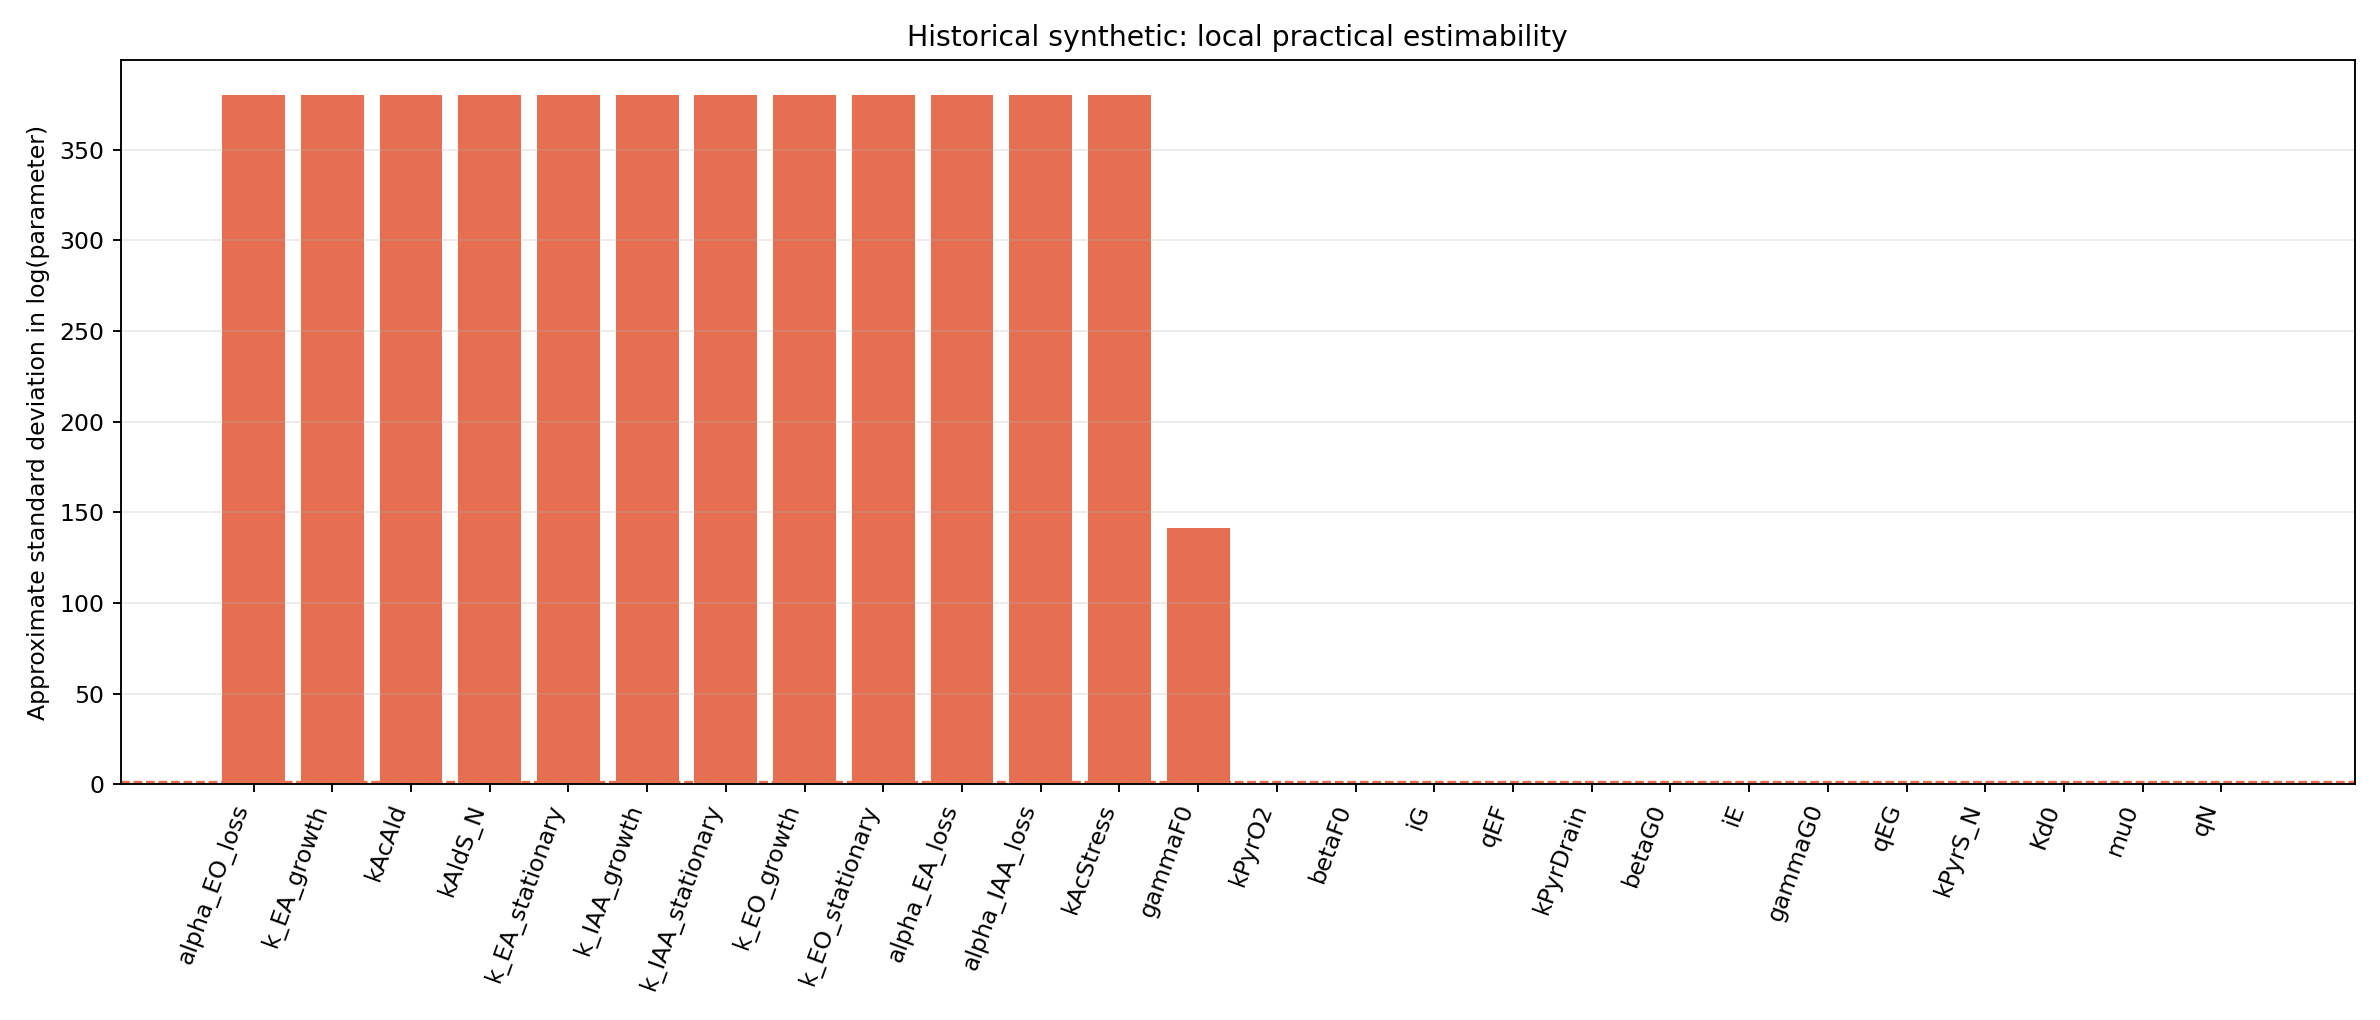

In [6]:
display(Image(filename=str(RESULTS / "figures" / "estimability_std_log.png")))

### Eigenvalue Diagnostics

,case,weak_direction,eigenvalue,dominant_parameters,dominant_abs_loadings
0,historical_synthetic_only,1,0.0,"kAldS_N, alpha_EO_loss, kPyrS_N, qN, betaG0, b...","1.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000"
1,historical_synthetic_only,2,0.0,"kAcAld, alpha_EO_loss, kPyrS_N, qN, betaG0, be...","1.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000"
2,historical_synthetic_only,3,0.0,"kAcStress, alpha_EO_loss, kPyrS_N, qN, betaG0,...","1.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000"
3,historical_synthetic_only,4,0.0,"k_EA_growth, alpha_EO_loss, kPyrS_N, qN, betaG...","1.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000"
4,historical_synthetic_only,5,0.0,"k_EA_stationary, alpha_EO_loss, kPyrS_N, qN, b...","1.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000"
5,historical_synthetic_only,6,0.0,"k_IAA_growth, alpha_EO_loss, kPyrS_N, qN, beta...","1.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000"
6,historical_synthetic_only,7,0.0,"k_IAA_stationary, alpha_EO_loss, kPyrS_N, qN, ...","1.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000"
7,historical_synthetic_only,8,0.0,"k_EO_growth, alpha_EO_loss, kPyrS_N, qN, betaG...","1.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000"


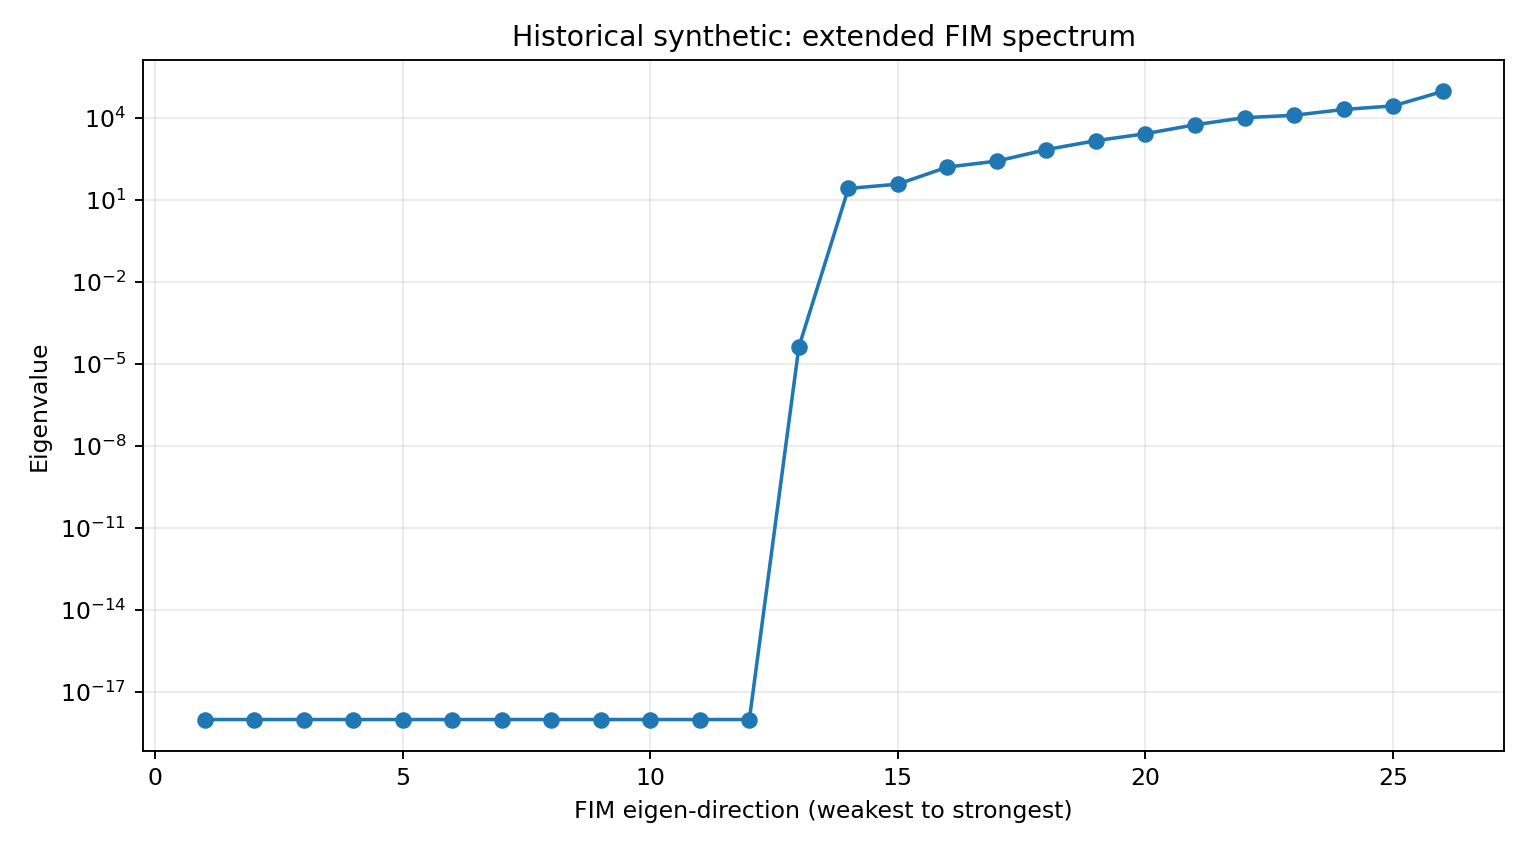

In [7]:
weak = pd.read_csv(RESULTS / "weak_directions_extended.csv")
display(weak)
display(Image(filename=str(RESULTS / "figures" / "extended_fim_eigenvalues.png")))

### Profile Likelihood

In [8]:
profile_summary = pd.read_csv(RESULTS / "profile_likelihood_summary_core.csv")
profile = pd.read_csv(RESULTS / "profile_likelihood_core.csv")
display(profile_summary)
display(profile)

,case,parameter,n_success,max_lr_stat,crosses_left_95,crosses_right_95,profile_identifiable_95,chi2_95_threshold
0,historical_synthetic_only,Kd0,4,399.652047,True,True,True,3.841459
1,historical_synthetic_only,qN,4,7670.129332,True,True,True,3.841459


,case,profiled_parameter,theta_hat,theta_value,success,objective,lr_stat,chi2_95_threshold,error
0,historical_synthetic_only,Kd0,0.000720,0.000360,True,9556.935516,254.462721,3.841459,NaN
1,historical_synthetic_only,Kd0,0.000720,0.000720,True,9302.472796,0.000002,3.841459,NaN
2,historical_synthetic_only,Kd0,0.000720,0.000900,True,9346.885126,44.412332,3.841459,NaN
3,historical_synthetic_only,Kd0,0.000720,0.001441,True,9702.124841,399.652047,3.841459,NaN
4,historical_synthetic_only,qN,0.008781,0.004390,True,16972.602126,7670.129332,3.841459,NaN
5,historical_synthetic_only,qN,0.008781,0.008781,True,9302.472796,0.000002,3.841459,NaN
6,historical_synthetic_only,qN,0.008781,0.010976,True,9726.742291,424.269497,3.841459,NaN
7,historical_synthetic_only,qN,0.008781,0.017562,True,11288.429679,1985.956884,3.841459,NaN


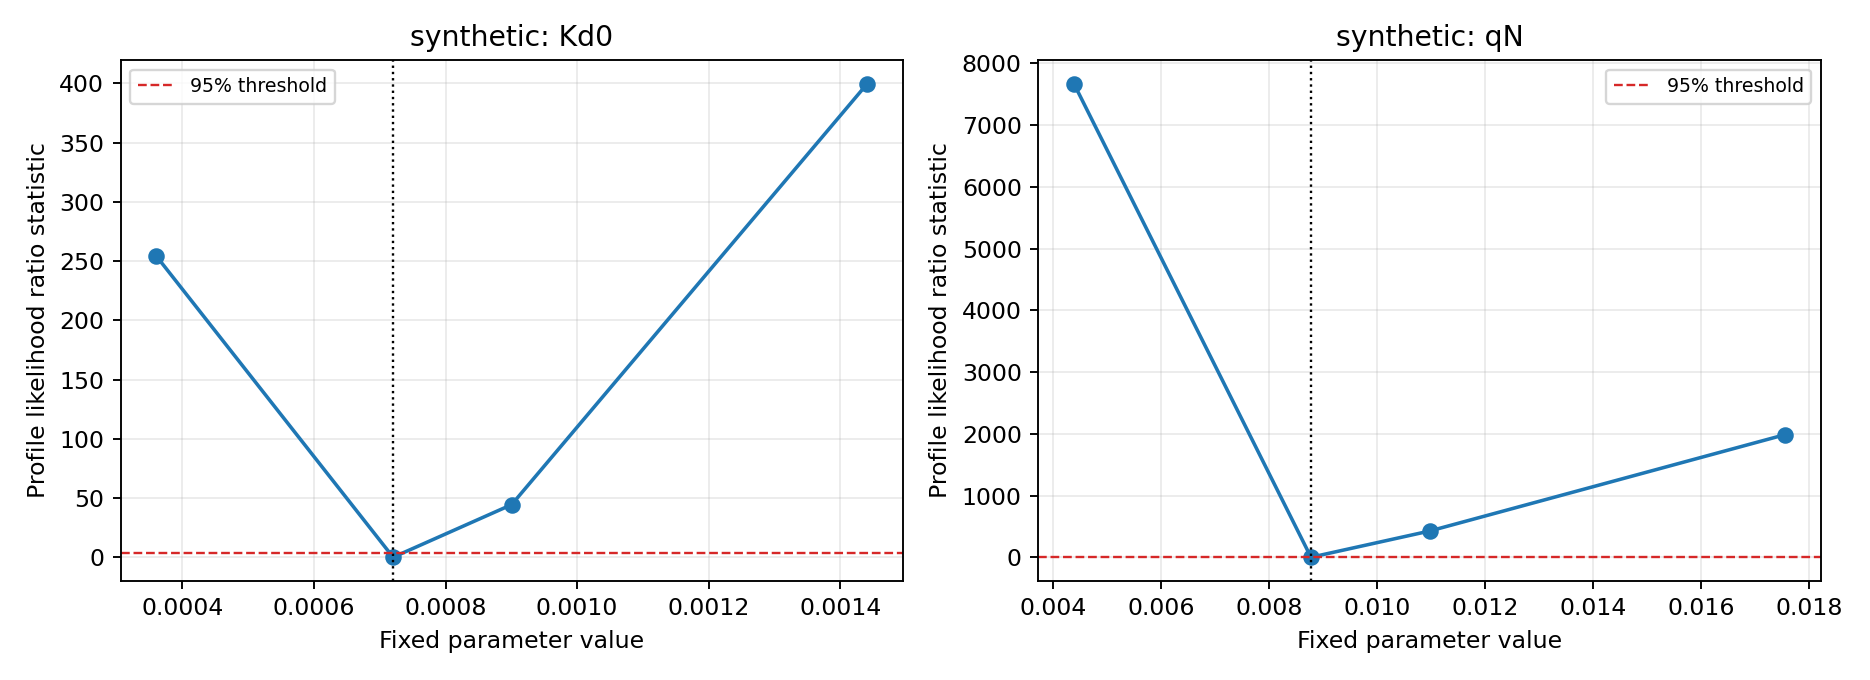

In [9]:
display(Image(filename=str(RESULTS / "figures" / "profile_likelihood.png")))

### Curve-Fit Checks

In [10]:
core_curve_metrics = pd.read_csv(RESULTS / "core_fit_metrics_by_batch_state.csv")
secondary_curve_metrics = pd.read_csv(RESULTS / "secondary_fit_metrics_by_batch_state.csv")
display(core_curve_metrics.groupby("state").agg(n=("n", "sum"), median_RMSE=("rmse", "median"), max_RMSE=("rmse", "max")))
display(secondary_curve_metrics.groupby("state").agg(n=("n", "sum"), median_RMSE=("rmse", "median"), max_RMSE=("rmse", "max")))

,n,median_RMSE,max_RMSE
state,,,
E,40,6.108259,8.342202
F,86,5.099145,9.369920
G,86,7.812633,15.112370
Gly,85,0.517523,1.205908
N,83,0.080697,0.126256
X,76,0.395513,0.610799
Xd,86,0.466724,0.569586


,n,median_RMSE,max_RMSE
state,,,
Pyr,86,16.65485,30.506866


## Takeaways

In [11]:
report = (RESULTS / "estimability_historical_synthetic_report.md").read_text(encoding="utf-8")
print(report)

# Historical synthetic estimability analysis

## Scope

This is an independent calibration and estimability analysis using only the historical `synthetic` medium subset. It is not a row-filtered view of the joint historical fit.

No matching continuous process-sensor archive was supplied for these synthetic historical batches.

The core kinetic block is re-estimated. Secondary and aroma parameters are evaluated conditionally at the shared prior values, matching the logic of `fermentation_estimability_old_vs_lot1`.

## Core fit

| fit                       |   n_batches | mediums   | parameters                                             |   n_parameters | success   |   status | message                                    |   nfev |   initial_wsse |   final_wsse |   n_residuals |   dof |   wsse_per_residual |   wsse_per_dof |   l2_lambda |   l2_parameters | best_seed                  |
|:--------------------------|------------:|:----------|:-----------------------------------------------